# Análise Exploratória dos Dados de Segurança do ISP

## Configurações iniciais do projeto

Importando as bibliotecas e dados

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [22]:
with open("../datasets/dataframe.pkl","rb") as file:
    df = pickle.load(file)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8880 entries, 17389 to 37510
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   cisp                        8880 non-null   int64         
 1   mes                         8880 non-null   int64         
 2   ano                         8880 non-null   int64         
 3   mes_ano                     8880 non-null   datetime64[ns]
 4   aisp                        8880 non-null   int64         
 5   risp                        8880 non-null   int64         
 6   munic                       8880 non-null   object        
 7   mcirc                       8880 non-null   int64         
 8   regiao                      8880 non-null   object        
 9   hom_doloso                  8880 non-null   int64         
 10  lesao_corp_morte            8880 non-null   int64         
 11  latrocinio                  8880 non-null   int64       

Configurando visual dos gráficos

In [23]:
sequentialpalette = sns.color_palette('inferno')
qualitativepalette = sns.color_palette('colorblind')

sns.set_palette(palette=sequentialpalette)

sns.set_style("whitegrid")

In [24]:
# pegar apenas os dados da Capital e da Baixada
df = df[df["regiao"].isin(["Capital", "Baixada Fluminense"])]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8880 entries, 17389 to 37510
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   cisp                        8880 non-null   int64         
 1   mes                         8880 non-null   int64         
 2   ano                         8880 non-null   int64         
 3   mes_ano                     8880 non-null   datetime64[ns]
 4   aisp                        8880 non-null   int64         
 5   risp                        8880 non-null   int64         
 6   munic                       8880 non-null   object        
 7   mcirc                       8880 non-null   int64         
 8   regiao                      8880 non-null   object        
 9   hom_doloso                  8880 non-null   int64         
 10  lesao_corp_morte            8880 non-null   int64         
 11  latrocinio                  8880 non-null   int64       

Percebemos que as regiões com mais incidência são bairros nobres, como Barra da Tijuca e Botafogo. Pensamos em duas interpretações disso:
1. Existe um viés no dado, pois esses contam apenas os furtos reportados e registrados.
2. Os dados ainda não estão normalizados pela quantidade de pessoas.
Podemos evitar o 2 ao relacionar com a população de cada bairro, porém precisamos de dados os quais ainda não temos para isso.

Verificamos que não temos nulos.

In [25]:
df.isna().sum()

cisp                         0
mes                          0
ano                          0
mes_ano                      0
aisp                         0
                            ..
encontro_ossada              0
pol_militares_mortos_serv    0
pol_civis_mortos_serv        0
registro_ocorrencias         0
fase                         0
Length: 65, dtype: int64

Verificando que os dados pegam o histórico de 2003 até 2026.

In [26]:
#print(f"Min: {df["ano"].min()}, Max: {df["ano"].max()}")

## Exploração de furtos e roubos em coletivos

Explorando a base de dados, achamos a coluna "roubo_em_coletivo" e "furto_coletivo", ambas que dizem respeito a segurança no transporte público.
Além disso, temos os campos "cisp", "aisp" e "risp", que servem de proxy com diferentes níveis de granularidade para as regiões para nas quais os incidentes foram reportados. Podemos ver mais a respeito sobre essas regiões [nesse documento](https://www.ispdados.rj.gov.br/Arquivos/Relacaodas%20RISP_AISP.pdf).

In [27]:
df_coletivo = df[["roubo_em_coletivo", "furto_coletivo", "risp", "aisp", "cisp"]]
df_coletivo.groupby("cisp").sum().sort_values("furto_coletivo")

,roubo_em_coletivo,furto_coletivo,risp,aisp
cisp,,,,
45,18,20,60,960
67,61,34,441,4998
51,31,36,441,3528
61,158,60,441,2205
48,120,103,441,3528
...,...,...,...,...
21,8156,3713,147,3234
4,2592,3724,147,735
10,930,4245,147,294


In [28]:
# sns.heatmap(df[["furto_coletivo", "cisp"]].corr())

df[["furto_coletivo", "roubo_em_coletivo", "hom_culposo", "hom_doloso"]].corr()

,furto_coletivo,roubo_em_coletivo,hom_culposo,hom_doloso
furto_coletivo,1.000000,0.198912,0.069322,-0.083733
roubo_em_coletivo,0.198912,1.000000,0.207527,0.320314
hom_culposo,0.069322,0.207527,1.000000,0.302417
hom_doloso,-0.083733,0.320314,0.302417,1.000000


### Roubos e furtos em coletivos através do tempo
Observando os dados através do tempo categorizados por risp, vemos que os roubos em coletivo tiveram um aumento de reportagem em 2016, mas uma queda durante a pandemia, de forma a se estabilizar em valore semelhantes aos anteriores a 2013.
Os furtos rapidamente se recuperaram no pós pandemia.

C:\Users\rhena\AppData\Local\Temp\ipykernel_18448\3330847888.py:2: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(data=df, x="ano", y="roubo_em_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)
C:\Users\rhena\AppData\Local\Temp\ipykernel_18448\3330847888.py:4: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(data=df, x="ano", y="furto_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)


<Axes: xlabel='ano', ylabel='furto_coletivo'>

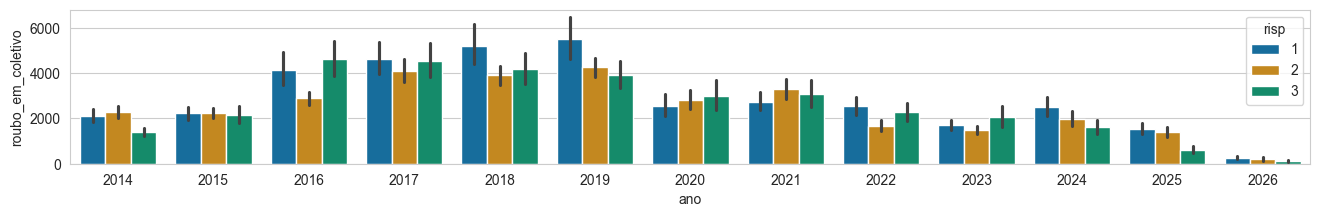

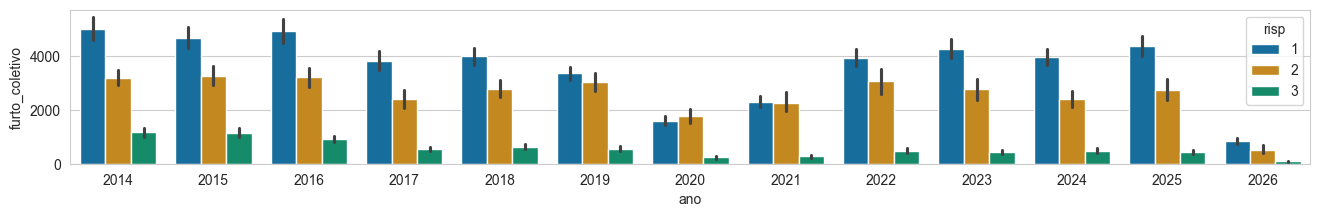

In [29]:

plt.figure(figsize=(16,2))
sns.barplot(data=df, x="ano", y="roubo_em_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)
plt.figure(figsize=(16,2))
sns.barplot(data=df, x="ano", y="furto_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)


Vemos que os furtos e roubos em coletivo são uma parte bem pequena dos furtos e roubos totais.

<Axes: xlabel='ano', ylabel='total_furtos'>

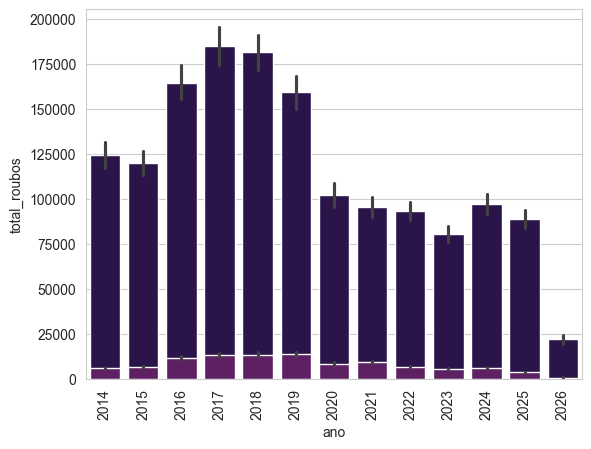

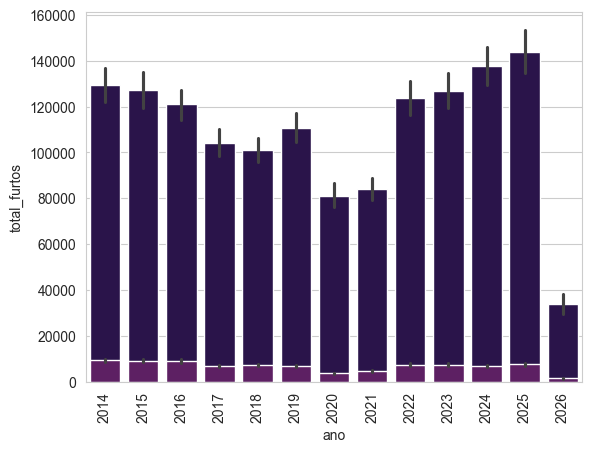

In [30]:
plt.figure()
plt.xticks(rotation=90)
sns.barplot(data=df, x="ano", y="total_roubos", estimator="sum")
sns.barplot(data=df, x="ano", y="roubo_em_coletivo", estimator="sum")
plt.figure()
plt.xticks(rotation=90)
sns.barplot(data=df, x="ano", y="total_furtos", estimator="sum")
sns.barplot(data=df, x="ano", y="furto_coletivo", estimator="sum")

### Buscando correlações entre as colunas
Primeiramente, uma visão geral da correlação

<Axes: >

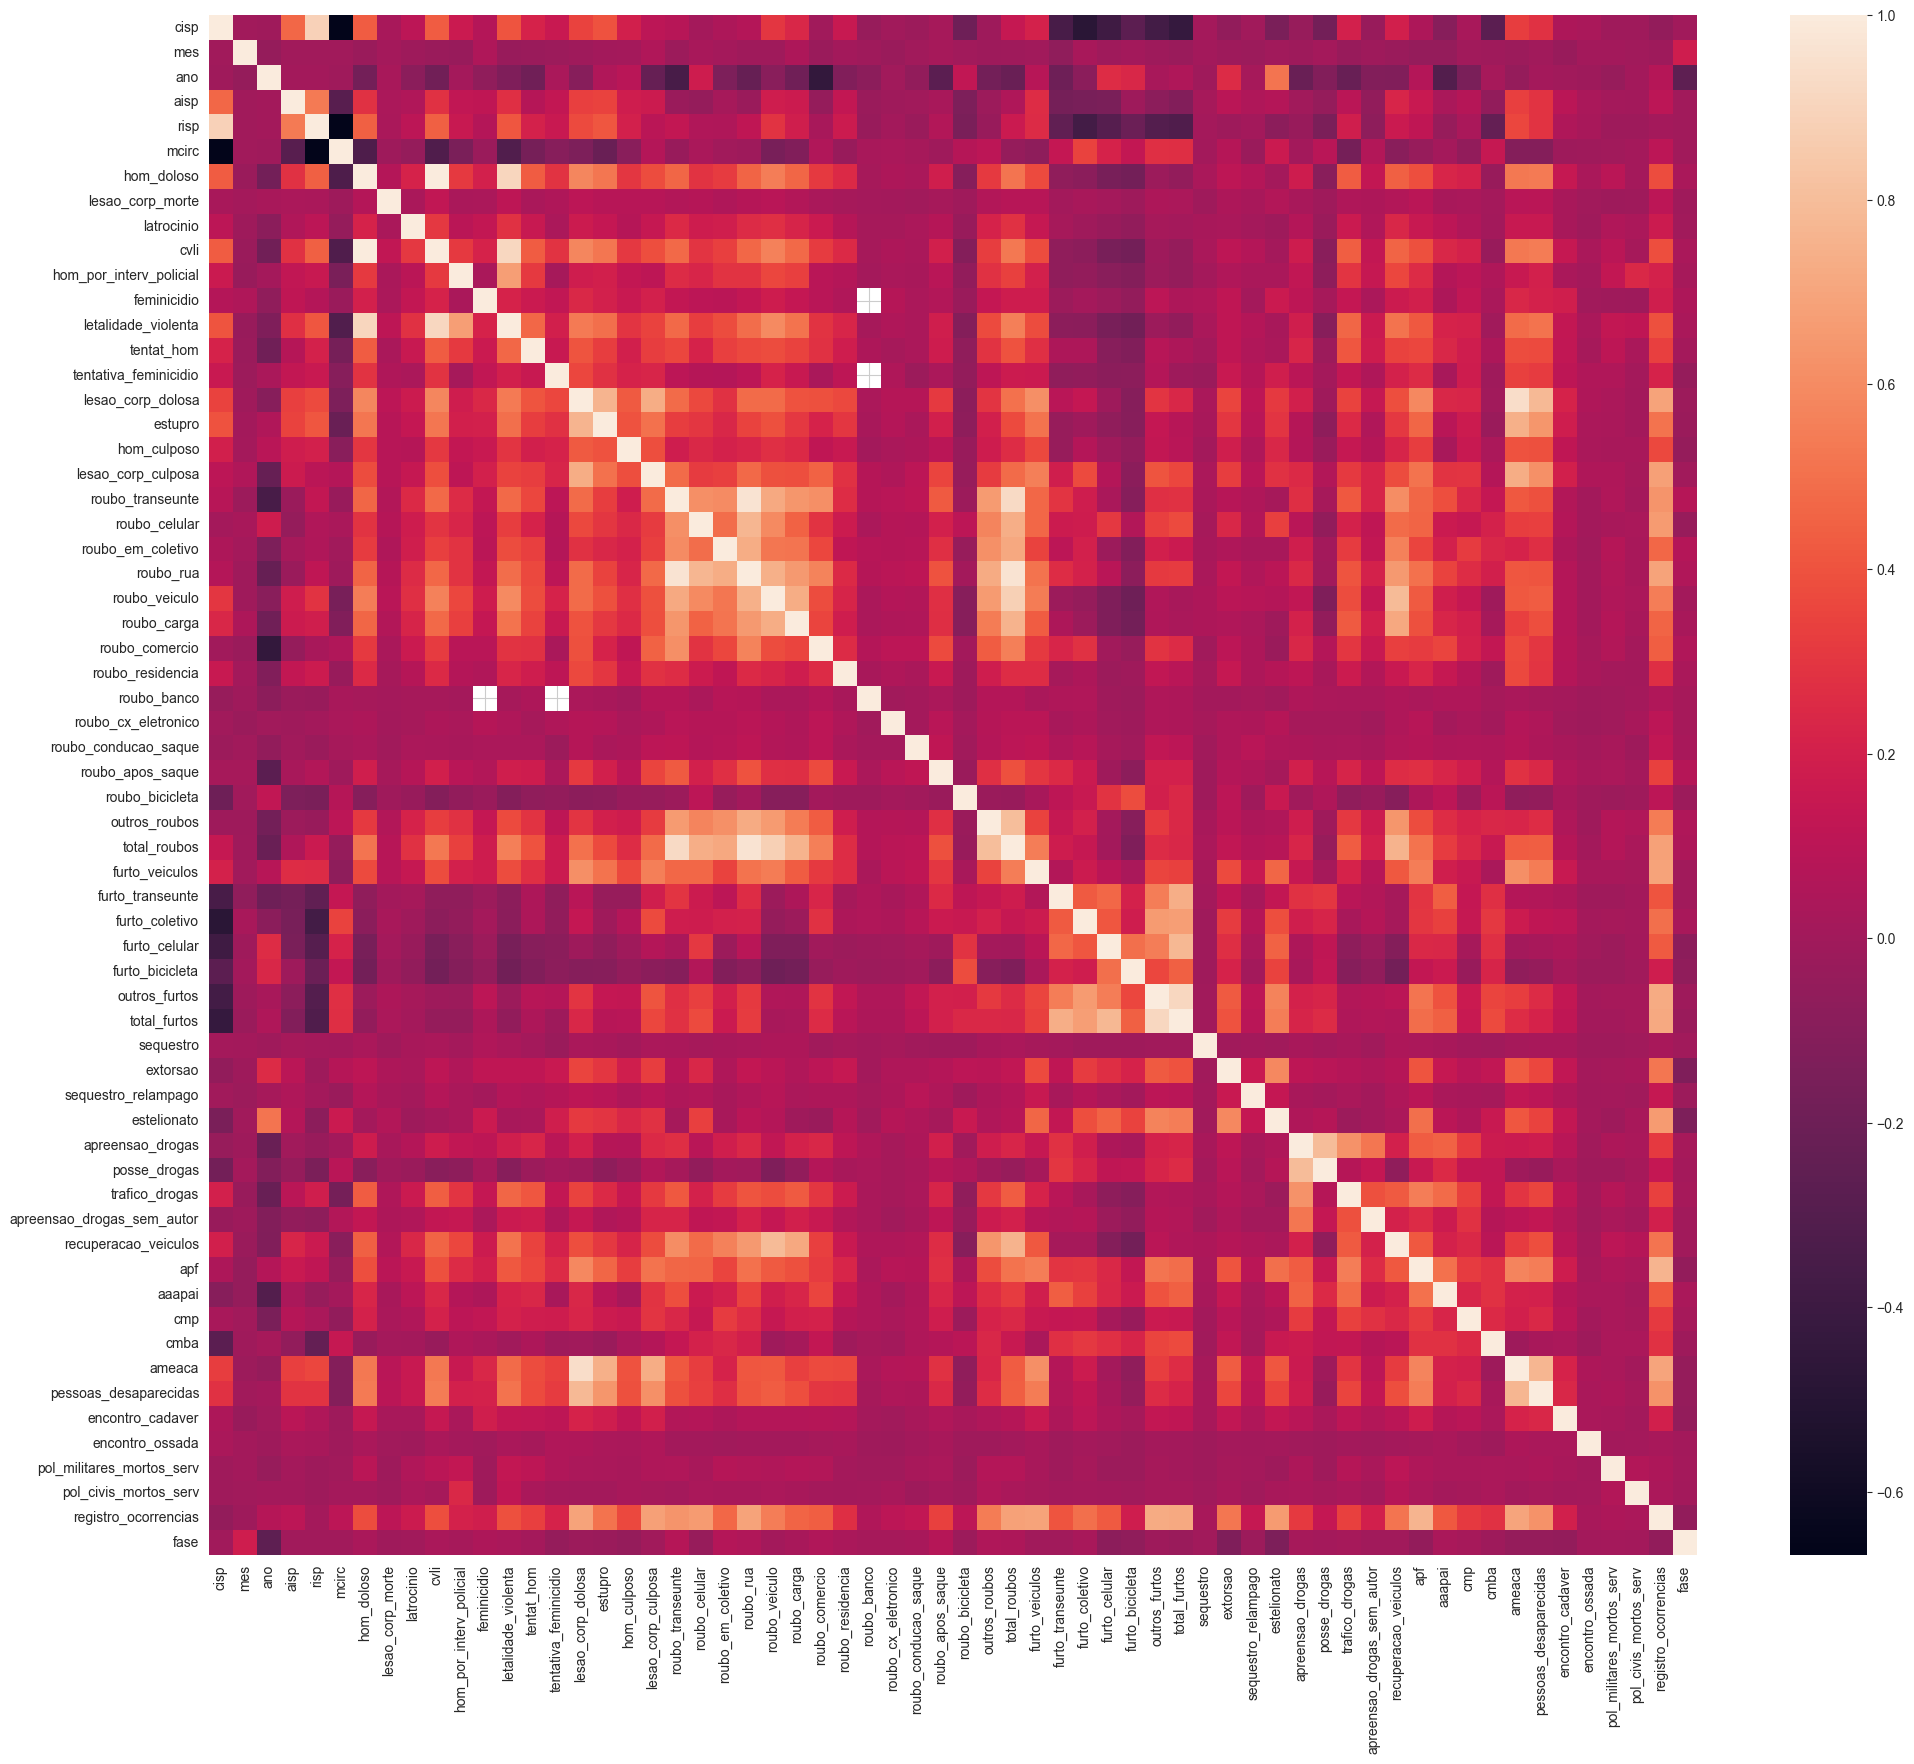

In [31]:
dfnumerical = df.select_dtypes(include=np.number)

plt.figure(figsize=(24,20))
sns.heatmap(dfnumerical.corr())

Selecionando mais delicadamente quais colunas visualizar no heatmap

Text(0.5, 1.0, 'Correlação com Roubo em Coletivo > 0.2')

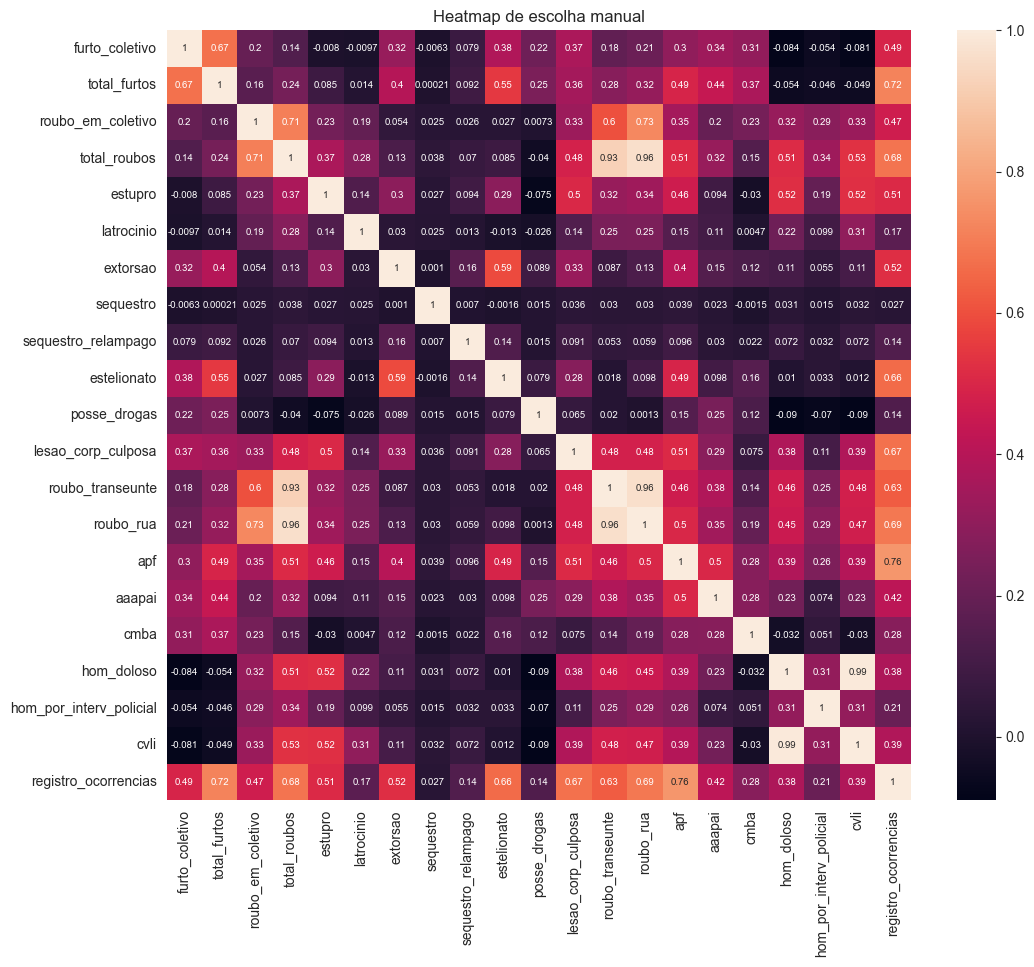

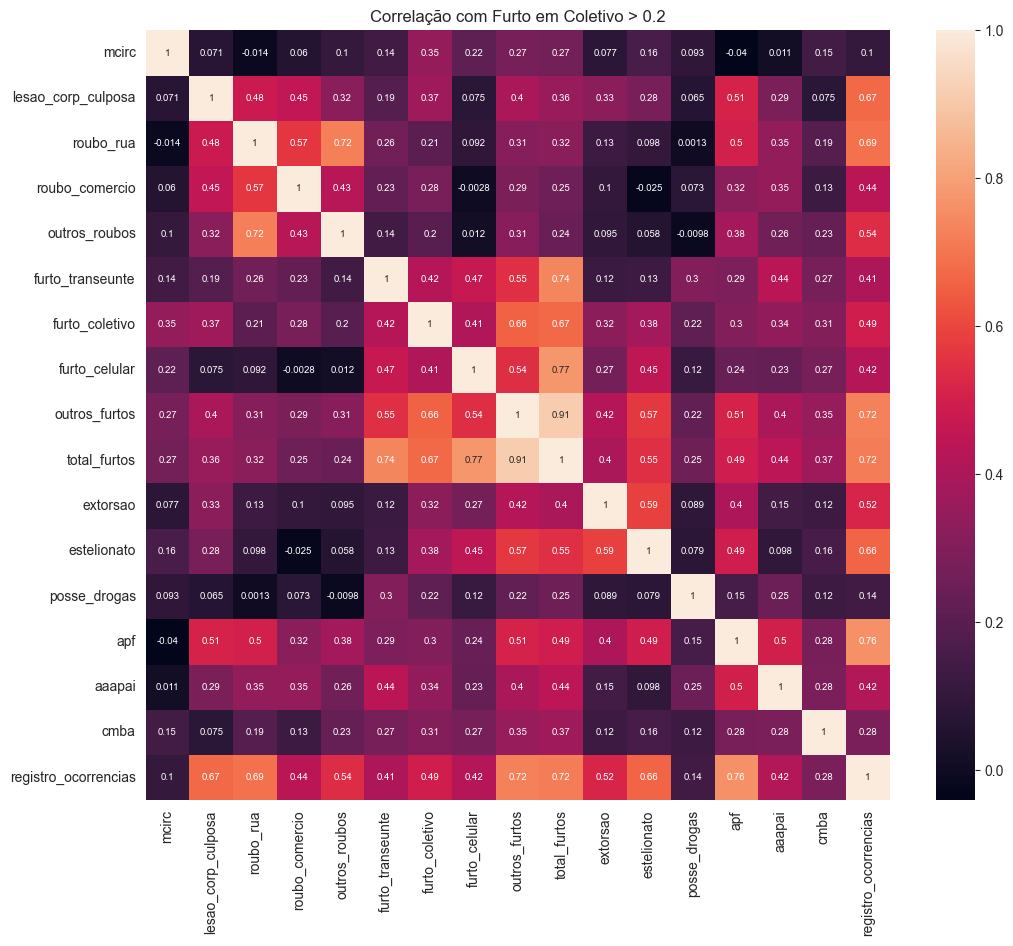

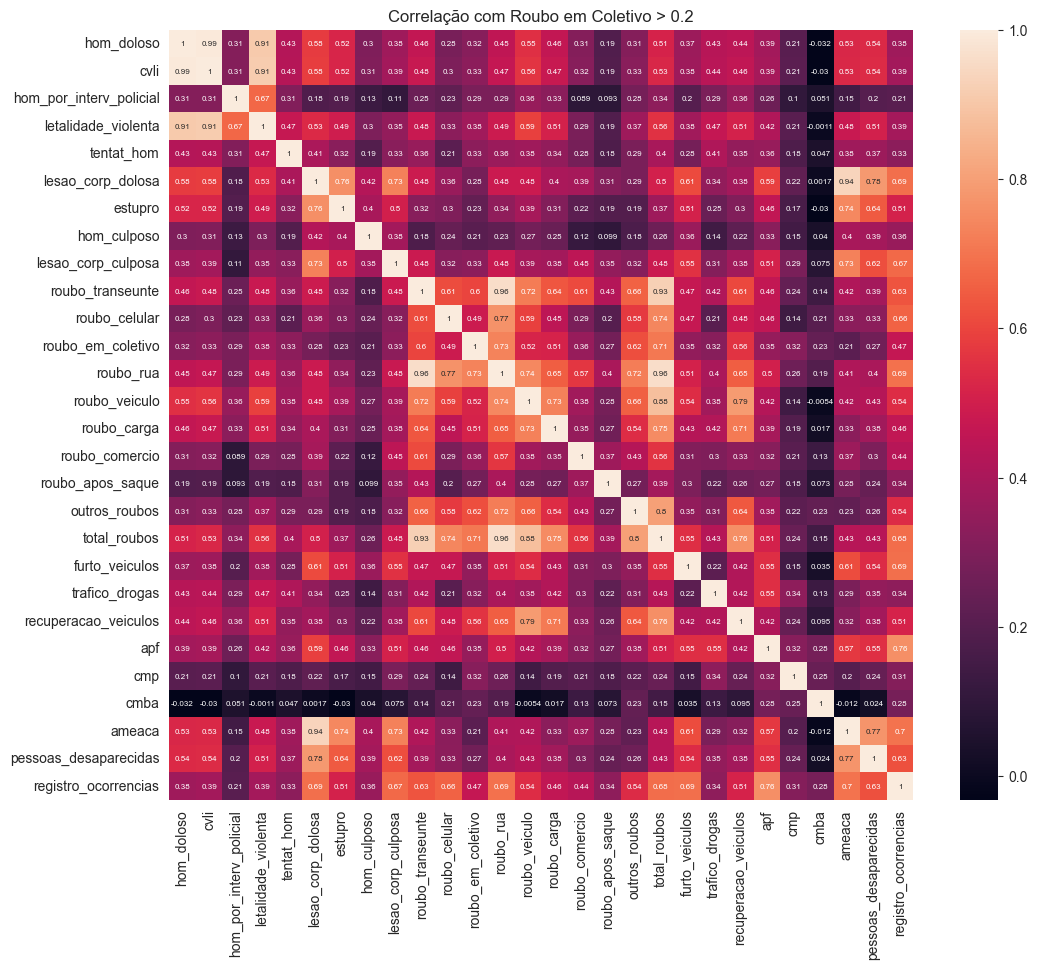

In [32]:
dfheatmapmanual = df[["furto_coletivo", "total_furtos", 
                "roubo_em_coletivo", "total_roubos",
                "estupro",
                "latrocinio",
                "extorsao",
                "sequestro", "sequestro_relampago",
                "estelionato",
                "posse_drogas",
                "lesao_corp_culposa",
                "roubo_transeunte", "roubo_rua",
                "apf", "aaapai", "cmba", # não faço ideia do que seja isso, mas tem uma correlação forte com furto em coletivo
                "hom_doloso", "hom_por_interv_policial",
                "cvli",                  # não faço ideia do que seja isso, mas tem uma correlação forte com roubo em coletivo
                "registro_ocorrencias"]]


plt.figure(figsize=(12,10))
sns.heatmap(dfheatmapmanual.corr(), annot=True, annot_kws={"size": "x-small"}).set_title("Heatmap de escolha manual")

# Fazendo o heatmap somente dos valores que ficam acima de um dado valor (threshold)
threshold = 0.2

dfheatmapcorrfurto = dfnumerical[dfnumerical.corr()[dfnumerical.corr()["furto_coletivo"] > threshold]["furto_coletivo"].keys()].corr()
plt.figure(figsize=(12,10))
sns.heatmap(dfheatmapcorrfurto, annot=True, annot_kws={"size": "x-small"}).set_title(f"Correlação com Furto em Coletivo > {threshold}")

dfheatmapcorrroubo = dfnumerical[dfnumerical.corr()[dfnumerical.corr()["roubo_em_coletivo"] > threshold]["roubo_em_coletivo"].keys()].corr()
plt.figure(figsize=(12,10))
sns.heatmap(dfheatmapcorrroubo, annot=True, annot_kws={"size": "xx-small"}).set_title(f"Correlação com Roubo em Coletivo > {threshold}")

C:\Users\rhena\AppData\Roaming\Python\Python314\site-packages\seaborn\axisgrid.py:1513: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  func(x=vector, **plot_kwargs)
C:\Users\rhena\AppData\Roaming\Python\Python314\site-packages\seaborn\axisgrid.py:1513: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  func(x=vector, **plot_kwargs)
C:\Users\rhena\AppData\Roaming\Python\Python314\site-packages\seaborn\axisgrid.py:1513: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  func(x=vector, **plot_kwargs)
C:\Users\rhena\AppData\Roaming\Python\Python314\site-packages\seaborn\axisgrid.py:1513: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  func(x=vector, **plot_kwargs)
C:\Users\rhena\AppData\Roaming\Python\Python314\site-packages\seaborn\axisgrid.py:1513: UserWarning: The palette list has more values (10) t

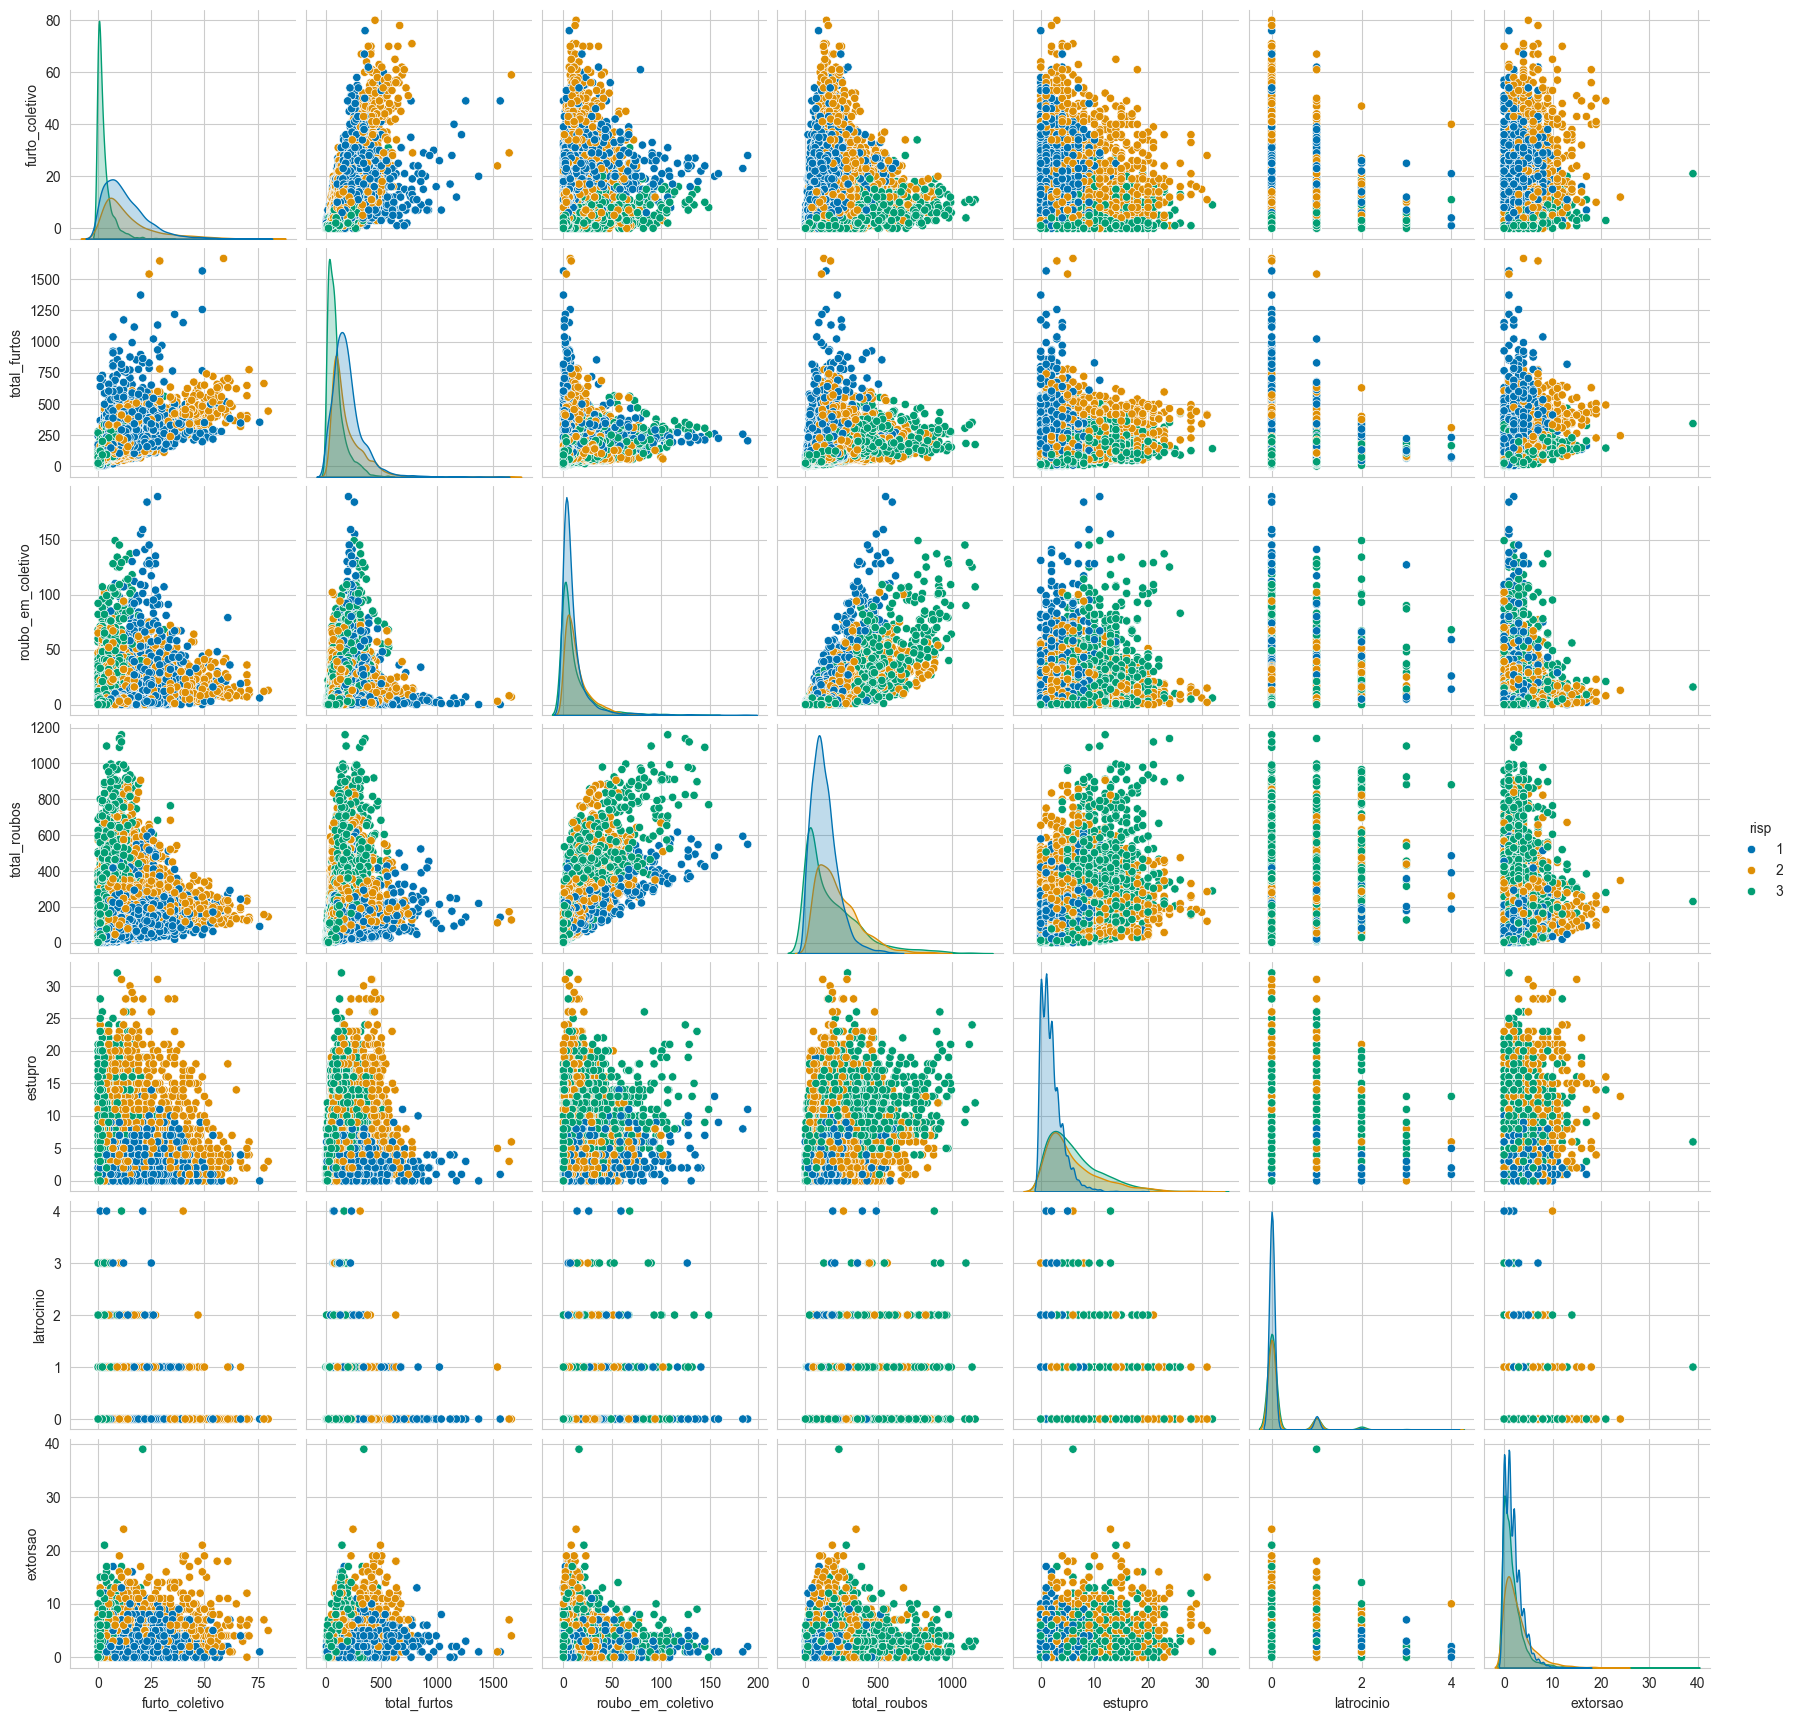

In [33]:
dfpair = df[["furto_coletivo", "total_furtos", 
                "roubo_em_coletivo", "total_roubos",
                "risp",
                "estupro",
                "latrocinio",
                "extorsao"]]

sns.pairplot(dfpair, hue="risp", palette=qualitativepalette) 